In [ ]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
from src.analysis import *


    
df = pd.read_csv('../data/flight_data_2024.csv')

# Use the sample dataset below for faster testing during development
# df = pd.read_csv('../data/flight_data_2024_sample.csv') 

# Initial data exploration
print(df.info())
print(df.describe())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 10000 non-null  int64  
 1   month                10000 non-null  int64  
 2   day_of_month         10000 non-null  int64  
 3   day_of_week          10000 non-null  int64  
 4   fl_date              10000 non-null  str    
 5   op_unique_carrier    10000 non-null  str    
 6   op_carrier_fl_num    10000 non-null  float64
 7   origin               10000 non-null  str    
 8   origin_city_name     10000 non-null  str    
 9   origin_state_nm      10000 non-null  str    
 10  dest                 10000 non-null  str    
 11  dest_city_name       10000 non-null  str    
 12  dest_state_nm        10000 non-null  str    
 13  crs_dep_time         10000 non-null  int64  
 14  dep_time             9884 non-null   float64
 15  dep_delay            9884 non-null   float64
 16

In [2]:
# Data cleaning and feature engineering from src/analysis.py
df = clean_data(df)
df = add_delay_indicator(df)
df = add_dep_hour(df)

In [18]:
# Compute all analytics and unpack into variables
analytics = compute_all_analytics(df)
avg_delay_by_dep_hour = analytics['avg_delay_by_dep_hour']
avg_arr_delay_by_carrier = analytics['avg_arr_delay_by_carrier']
delay_rate_pct_by_carrier = analytics['delay_rate_pct_by_carrier']
delay_totals_by_delay_type = analytics['delay_totals_by_delay_type']
delay_totals_by_type_per_carrier = analytics['delay_totals_by_type_per_carrier']

KeyError: 'delay_totals_by_type_per_carrier'

In [4]:
# Basic statistics/ sanity checks
print("Total Flights:", df.shape[0])
print("Avg Arrival Delay:", df['arr_delay'].mean())



Total Flights: 10000
Avg Arrival Delay: 7.4213


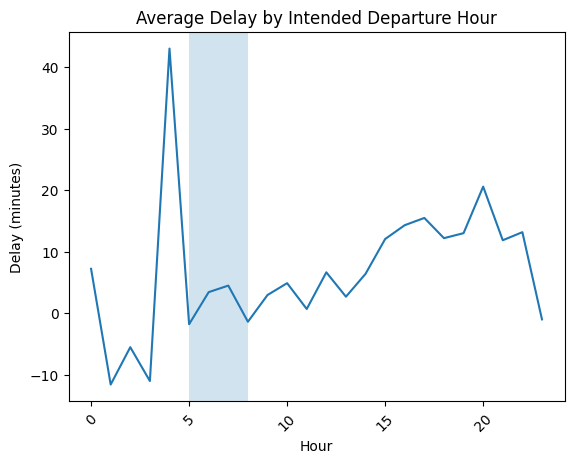

In [5]:
# Average delay by intended departure hour (HH)

avg_delay_by_dep_hour.plot()
plt.title("Average Delay by Intended Departure Hour")
plt.xlabel("Hour")
plt.ylabel("Delay (minutes)")
plt.xticks(rotation=45)
plt.savefig('../visuals/avg_delays_by_dep_hour.png', bbox_inches='tight')
plt.axvspan(5, 8, alpha=0.2)  # highlight best departure timewindow
plt.show()

In [6]:
# Departure hours with lowest average delay
avg_delay_by_dep_hour.sort_values(ascending=True).head(5)

# Departure hours with highest average delay
# avg_delay_by_dep_hour.sort_values(ascending=False).head(5)

dep_hour
1   -11.571429
3   -11.000000
2    -5.500000
5    -1.771127
8    -1.370206
Name: arr_delay, dtype: float64

{'AA': 'American Airlines', 'F9': 'Frontier Airlines', 'B6': 'JetBlue Airways', 'OH': 'PSA Airlines', 'G4': 'Allegiant Air', 'NK': 'Spirit Airlines', 'OO': 'SkyWest Airlines', 'MQ': 'Envoy Air', 'UA': 'United Airlines', 'WN': 'Southwest Airlines', 'AS': 'Alaska Airlines', 'HA': 'Hawaiian Airlines', 'DL': 'Delta Air Lines', '9E': 'Endeavor Air', 'YX': 'Republic Airways'}


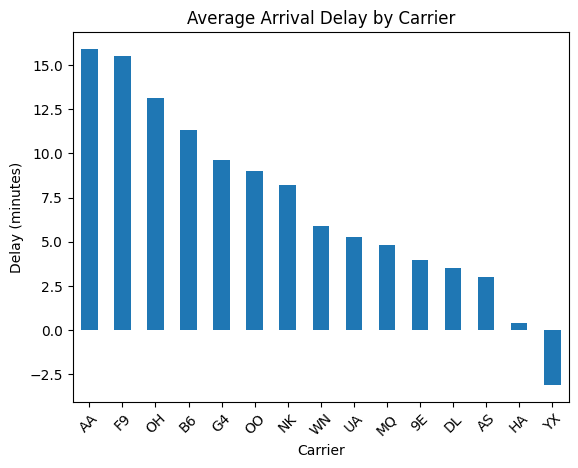

In [7]:
# Carrier Key
print(carrier_code_map)

# Average delays by carrier (minutes)
avg_arr_delay_by_carrier.sort_values(ascending=False).plot(kind='bar')
plt.title("Average Arrival Delay by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Delay (minutes)")
plt.xticks(rotation=45)
plt.savefig('../visuals/avg_delay_by_carrier.png', bbox_inches='tight')
plt.show()


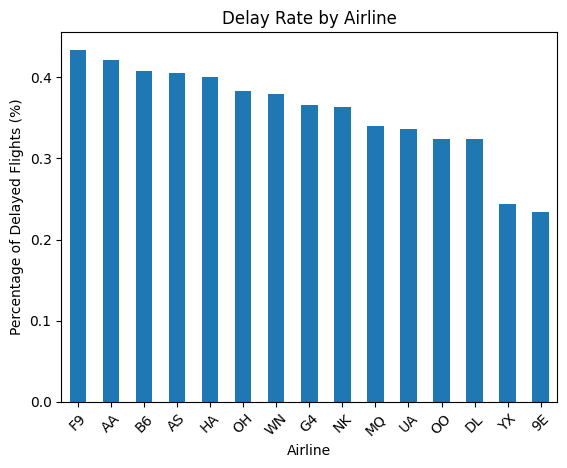

In [8]:
# Delay rate by carrier (%)

delay_rate_pct_by_carrier.sort_values(ascending=False).plot(kind='bar')
plt.title("Delay Rate by Airline")
plt.xlabel("Airline")
plt.ylabel("Percentage of Delayed Flights (%)")
plt.xticks(rotation=45)
plt.savefig('../visuals/delay_rate_by_airline.png', bbox_inches='tight')
plt.show()

In [9]:
# Top 5 Best carriers by delay rate
delay_rate_pct_by_carrier.sort_values(ascending=True).rename(index=carrier_code_map).head(5)

op_unique_carrier
Endeavor Air        0.233813
Republic Airways    0.244240
Delta Air Lines     0.323509
SkyWest Airlines    0.324074
United Airlines     0.335915
Name: is_delayed, dtype: float64

In [10]:
# Top 5 worst carriers by delay rate
delay_rate_pct_by_carrier.sort_values(ascending=False).rename(index=carrier_code_map).head(5)

op_unique_carrier
Frontier Airlines    0.433898
American Airlines    0.420939
JetBlue Airways      0.407855
Alaska Airlines      0.405573
Hawaiian Airlines    0.400000
Name: is_delayed, dtype: float64

In [11]:
# Combine the average arrival delay, and delay rate into a single DataFrame for easier comparison
combined = pd.DataFrame({
    'avg_arr_delay_min': avg_arr_delay_by_carrier.rename(index=carrier_code_map),
    'delay_rate_pct': delay_rate_pct_by_carrier.rename(index=carrier_code_map)
})

print(combined.sort_values(by='delay_rate_pct', ascending=False))

                    avg_arr_delay_min  delay_rate_pct
op_unique_carrier                                    
Frontier Airlines           15.522034        0.433898
American Airlines           15.906137        0.420939
JetBlue Airways             11.308157        0.407855
Alaska Airlines              3.027864        0.405573
Hawaiian Airlines            0.421053        0.400000
PSA Airlines                13.156442        0.383436
Southwest Airlines           5.901088        0.378833
Allegiant Air                9.616279        0.366279
Spirit Airlines              8.207756        0.362881
Envoy Air                    4.807882        0.339901
United Airlines              5.272023        0.335915
SkyWest Airlines             9.007407        0.324074
Delta Air Lines              3.506511        0.323509
Republic Airways            -3.101382        0.244240
Endeavor Air                 3.989209        0.233813


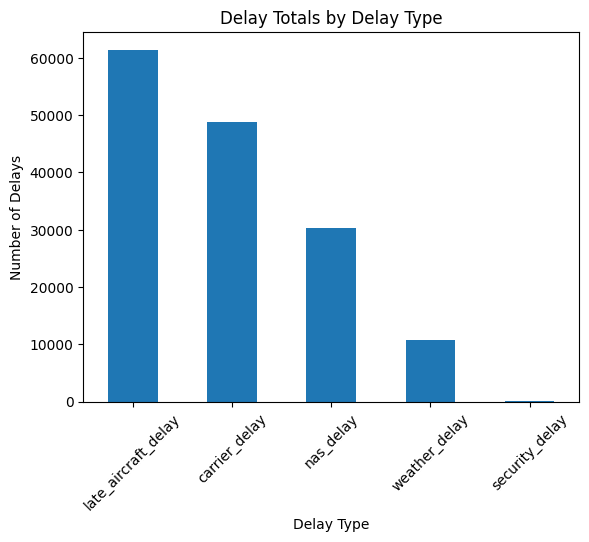

In [12]:
# Calculate total delay minutes for each type of delay

delay_totals_by_delay_type.sort_values(ascending=False).plot(kind='bar')
plt.title('Delay Totals by Delay Type')
plt.xlabel('Delay Type')
plt.ylabel('Number of Delays')
plt.xticks(rotation=45)
plt.savefig('../visuals/delay_totals_by_delay_type', bbox_inches='tight' )
plt.show()

In [ ]:
# which delay type is the biggest for each airline
delay_totals_by_type_per_carrier.idxmax(axis=1) 

                    carrier_delay  weather_delay  nas_delay  security_delay  \
op_unique_carrier                                                             
Endeavor Air                 1532            835        387               0   
American Airlines            9430           2163       4705               6   
Alaska Airlines               814             34       1074               0   
JetBlue Airways              2747            154       1540              19   
Delta Air Lines              7404            430       3265               0   
Frontier Airlines            1807            255       1276               0   
Allegiant Air                 989            294        813              14   
Hawaiian Airlines             295              0          8               0   
Envoy Air                    1169            492        956              16   
Spirit Airlines              1603             92       3085               0   
PSA Airlines                 1399            345    

op_unique_carrier
Endeavor Air                carrier_delay
American Airlines     late_aircraft_delay
Alaska Airlines       late_aircraft_delay
JetBlue Airways             carrier_delay
Delta Air Lines             carrier_delay
Frontier Airlines     late_aircraft_delay
Allegiant Air         late_aircraft_delay
Hawaiian Airlines           carrier_delay
Envoy Air             late_aircraft_delay
Spirit Airlines                 nas_delay
PSA Airlines          late_aircraft_delay
SkyWest Airlines            carrier_delay
United Airlines       late_aircraft_delay
Southwest Airlines    late_aircraft_delay
Republic Airways                nas_delay
dtype: str

In [14]:
# which airline has the biggest delay for each delay type
delay_totals_all.idxmax() 

carrier_delay           American Airlines
weather_delay            SkyWest Airlines
nas_delay               American Airlines
security_delay         Southwest Airlines
late_aircraft_delay     American Airlines
dtype: str

In [15]:
 # which delay type is the biggest for most airlines  
delay_totals_all.idxmax(axis=1).value_counts()

late_aircraft_delay    8
carrier_delay          5
nas_delay              2
Name: count, dtype: int64